In [1]:
import os
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    BatchNormalization,
    Flatten,
    Dense,
)
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import optimizers




2026-05-03 21:39:34.879447: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777844374.893088      56 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777844374.897328      56 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-05-03 21:39:34.914372: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

In [2]:
# Load CSV metadata
train_data = pd.read_csv("../input/aerial-cactus-identification/train.csv", dtype=str)
test_data = pd.read_csv(
    "../input/aerial-cactus-identification/sample_submission.csv", dtype=str
)




In [3]:
# Define image directories
train_path = "/kaggle/input/aerial-cactus-identification/train/"
test_path = "/kaggle/input/aerial-cactus-identification/test/"

print("Training Images:", len(os.listdir(train_path)))
print("Testing Images: ", len(os.listdir(test_path)))




Training Images: 14176
Testing Images:  3326


In [4]:
# Image data generators
train_datagen = ImageDataGenerator(rescale=1 / 255.0, validation_split=0.20)
test_datagen = ImageDataGenerator(rescale=1 / 255.0)




In [5]:
bs = 100

# Ensure labels are strings for categorical mode
train_data["has_cactus"] = train_data["has_cactus"].astype(str)

train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_data,
    directory=train_path,
    x_col="id",
    y_col="has_cactus",
    subset="training",
    batch_size=bs,
    shuffle=True,
    class_mode="categorical",
    target_size=(32, 32),
)

valid_generator = train_datagen.flow_from_dataframe(
    dataframe=train_data,
    directory=train_path,
    x_col="id",
    y_col="has_cactus",
    subset="validation",
    batch_size=bs,
    shuffle=False,
    class_mode="categorical",
    target_size=(32, 32),
)

test_generator = test_datagen.flow_from_dataframe(
    dataframe=test_data,
    directory=test_path,
    x_col="id",
    y_col=None,
    batch_size=bs,
    shuffle=False,
    class_mode=None,
    target_size=(32, 32),
)




Found 11340 validated image filenames belonging to 2 classes.
Found 2835 validated image filenames belonging to 2 classes.
Found 3325 validated image filenames.


In [6]:
# Steps per epoch
tr_steps = math.ceil(train_generator.samples / bs)
va_steps = math.ceil(valid_generator.samples / bs)
te_steps = math.ceil(test_generator.samples / bs)




In [7]:
# Build CNN model
cnn = Sequential()
cnn.add(Conv2D(28, (3, 3), activation="relu", padding="same", input_shape=(32, 32, 3)))
cnn.add(Conv2D(28, (3, 3), activation="relu", padding="same"))
cnn.add(MaxPooling2D(pool_size=(2, 2)))
cnn.add(BatchNormalization())

cnn.add(Conv2D(56, (3, 3), activation="relu", padding="same"))
cnn.add(Conv2D(56, (3, 3), activation="relu", padding="same"))
cnn.add(MaxPooling2D(pool_size=(2, 2)))
cnn.add(BatchNormalization())

cnn.add(Flatten())
cnn.add(Dense(128, activation="relu"))
cnn.add(BatchNormalization())
cnn.add(Dense(2, activation="softmax"))

cnn.summary()




/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-05-03 21:39:43.199088: W tensorflow/core/common_runtime/gpu/gpu_bfc_allocator.cc:47] Overriding orig_value setting because the TF_FORCE_GPU_ALLOW_GROWTH environment variable is set. Original config value was 0.
I0000 00:00:1777844383.199544      56 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 46866 MB memory:  -> device: 0, name: NVIDIA RTX A6000, pci bus id: 0000:46:00.0, compute capability: 8.6


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 28)     │           784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 28)     │         7,084 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 28)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 16, 16, 28)     │           112 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 56)     │        14,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 56)     │        28,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 56)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 8, 8, 56)       │           224 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3584)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       458,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 510,302 (1.95 MB)

 Trainable params: 509,878 (1.95 MB)

 Non-trainable params: 424 (1.66 KB)

In [8]:
opt = optimizers.Adam(learning_rate=0.001)
cnn.compile(loss="categorical_crossentropy", optimizer=opt, metrics=["accuracy"])

h1 = cnn.fit(
    train_generator,
    steps_per_epoch=tr_steps,
    epochs=80,
    validation_data=valid_generator,
    validation_steps=va_steps,
    verbose=1,
)




Epoch 1/80


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()
I0000 00:00:1777844385.519882     110 service.cc:148] XLA service 0x7f63e8003800 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1777844385.519913     110 service.cc:156]   StreamExecutor device (0): NVIDIA RTX A6000, Compute Capability 8.6
2026-05-03 21:39:45.558097: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1777844385.741369     110 cuda_dnn.cc:529] Loaded cuDNN version 90300
E0000 00:00:1777844386.603267     110 buffer_comparator.cc:157] Diff

  6/114 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - accuracy: 0.6104 - loss: 1.0224

I0000 00:00:1777844388.293418     110 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


114/114 ━━━━━━━━━━━━━━━━━━━━ 11s 54ms/step - accuracy: 0.8941 - loss: 0.3036 - val_accuracy: 0.7541 - val_loss: 0.7463
Epoch 2/80
114/114 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.9769 - loss: 0.0676 - val_accuracy: 0.7541 - val_loss: 0.4124
Epoch 3/80
114/114 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - accuracy: 0.9859 - loss: 0.0429 - val_accuracy: 0.9492 - val_loss: 0.1268
Epoch 4/80
114/114 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - accuracy: 0.9907 - loss: 0.0288 - val_accuracy: 0.8921 - val_loss: 0.2424
Epoch 5/80
114/114 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - accuracy: 0.9935 - loss: 0.0186 - val_accuracy: 0.9799 - val_loss: 0.0565
Epoch 6/80
114/114 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.9957 - loss: 0.0140 - val_accuracy: 0.8102 - val_loss: 0.8180
Epoch 7/80
114/114 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.9967 - loss: 0.0086 - val_accuracy: 0.7549 - val_loss: 1.7259
Epoch 8/80
114/114 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.9977 - loss: 0.0082 - val_accuracy: 0.96

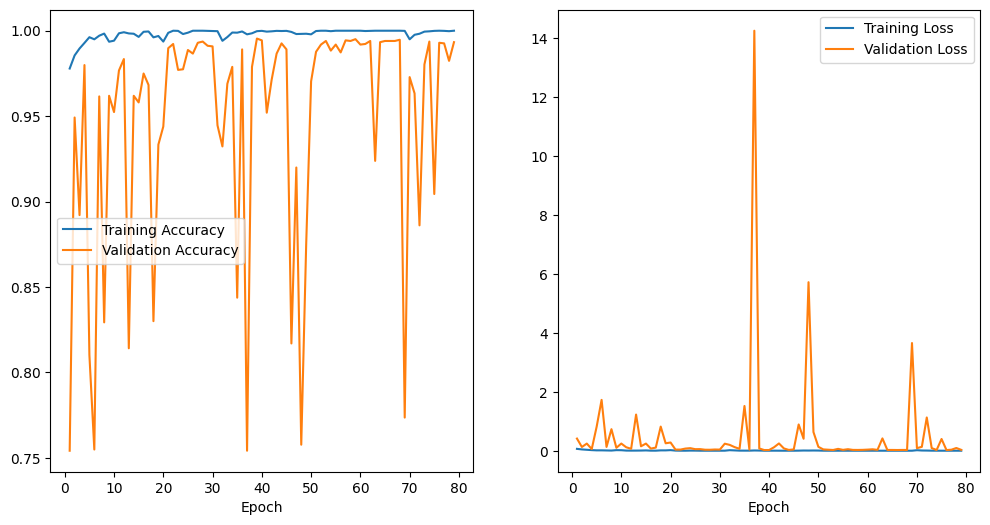

In [9]:
# Plot training history
start = 1
ep_rng = np.arange(start, len(h1.history["accuracy"]))

plt.figure(figsize=[12, 6])
plt.subplot(1, 2, 1)
plt.plot(ep_rng, h1.history["accuracy"][start:], label="Training Accuracy")
plt.plot(ep_rng, h1.history["val_accuracy"][start:], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(ep_rng, h1.history["loss"][start:], label="Training Loss")
plt.plot(ep_rng, h1.history["val_loss"][start:], label="Validation Loss")
plt.xlabel("Epoch")
plt.legend()
plt.show()




In [10]:
# Predict on test set
test_pred = cnn.predict(test_generator, steps=te_steps, verbose=1)




34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step


In [11]:
# Prepare submission
test_fnames = test_generator.filenames
prob_has_cactus = test_pred[:, 1]  # probability of class "1"

submission = pd.DataFrame({"id": test_fnames, "has_cactus": prob_has_cactus})
submission.to_csv("submission.csv", index=False)
print("Submission file saved as submission.csv")
print(submission.head())

Submission file saved as submission.csv
                                     id  has_cactus
0  09034a34de0e2015a8a28dfe18f423f6.jpg    1.000000
1  134f04305c795d6d202502c2ce3578f3.jpg    0.999999
2  41fad8d145e6c41868ce3617e30a2545.jpg    0.999999
3  35f8a11352c8d41b6231bb33d8d09f7e.jpg    0.999997
4  b77dc902b035887cbbc01920ce0e3151.jpg    1.000000
